In [44]:
# General imports
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Sklearn imports
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


In [45]:
# Convert 1D array to 2D array
def convert(array):
    length = len(array)
    new_shape = (length, 1)
    array = np.reshape(array, new_shape)
    return array


In [46]:
# Depickle: Training
TRAINING_FILE = open('data/train.pkl', 'rb')
train_data = pickle.load(TRAINING_FILE)

# Depickle: Testing
TESTING_FILE = open('data/test.pkl', 'rb')
test_data = pickle.load(TESTING_FILE)


In [47]:
# Extract arrays and convert to 2D

# Train: Feature
X_train = train_data[:, 0]
X_train = convert(X_train)

# Train: Label
Y_train = train_data[:, 1]
Y_train = convert(Y_train)

# Test: Feature
X_test = test_data[:, 0]
X_test = convert(X_test)

# Test: Label
Y_test = test_data[:, 1]
Y_test = convert(Y_test)


In [48]:
# Display training and testing data
print(train_data.shape)
print(test_data.shape)
print()

print(train_data[:3])
print()
print(test_data[:3])


(8000, 2)
(80, 2)

[[  27.42765666 3335.78295109]
 [  -4.96183456 2647.40265244]
 [ -27.86119551  520.73369536]]

[[  -15.029       -351.99223091]
 [  -25.977      -1807.03436449]
 [   -4.48          -9.00368   ]]


In [49]:
# Definitions
GRAPH_SIZE = (20, 10)
NUM_DATASETS = 16
TOTAL_SIZE = len(train_data)
DATASET_SIZE = int(TOTAL_SIZE/NUM_DATASETS)
MIN_ORDER = 1
MAX_ORDER = 16


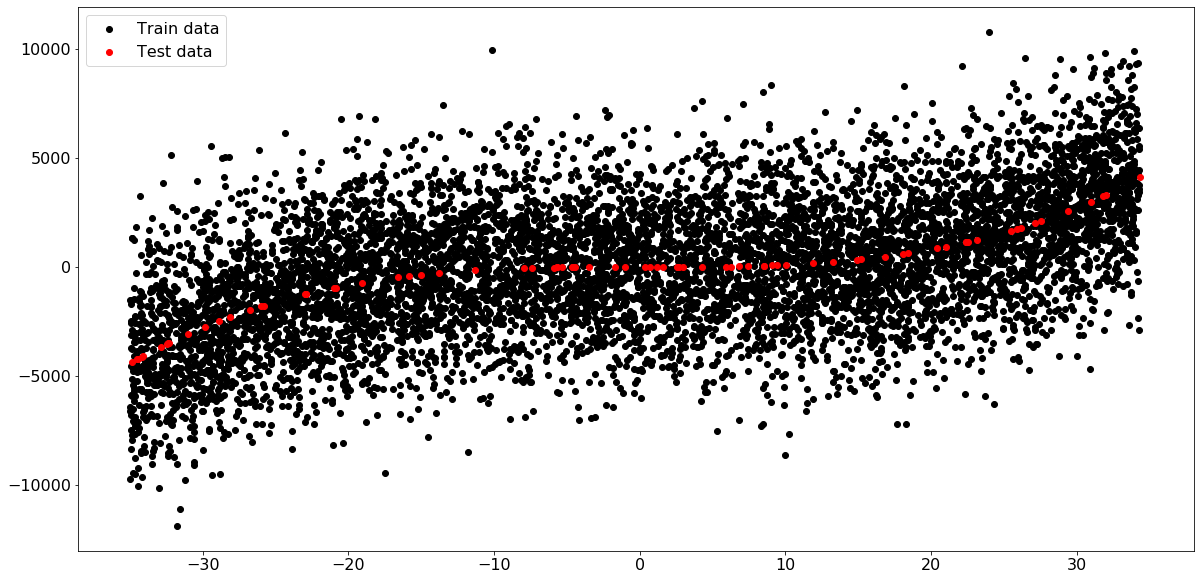

In [50]:
# Plot the graph
plt.figure(figsize=GRAPH_SIZE)

plt.scatter(X_train, Y_train, label="Train data", color='black')
plt.scatter(X_test, Y_test,  label="Test data", color='red')

plt.legend()
plt.show()


In [51]:
# Separate the dataset
np.random.shuffle(train_data)
test_data = np.sort(test_data, axis=0)
train_sets = []
for i in range(NUM_DATASETS):
    train_sets.append(train_data[500*i: 500*(i+1)])
print(train_sets[0])


[[   -16.54330101  -4211.96682115]
 [    26.56720468  -2998.40998661]
 [     1.88984859  -2083.35383655]
 [    31.63409376   1383.4648169 ]
 [    25.973955     1891.1027672 ]
 [   -26.80264343  -7742.86291146]
 [   -32.21960967  -6741.92675332]
 [    31.43948965   -695.92743908]
 [    -2.99924047  -1260.38200462]
 [     8.4718107    3260.05811131]
 [    11.15734018  -2110.72137655]
 [   -29.88921511   -150.4962788 ]
 [    -8.47945172  -3657.35083627]
 [   -17.77077829   1487.87714023]
 [   -33.27736204   -978.35718202]
 [   -31.63728102  -3654.82109377]
 [    18.71228941   -279.07970209]
 [     6.27045409    786.66595546]
 [    -8.4540218    2812.19687721]
 [   -32.79412632   1905.68233572]
 [    17.82461021    -24.67989068]
 [   -28.15995463  -1175.69420903]
 [     5.57428944   2111.12450907]
 [   -34.21999438  -5577.01676069]
 [   -12.28621873  -2095.89180015]
 [    14.93951777   2555.5561533 ]
 [     8.57747412    923.74744445]
 [   -25.23649277  -1774.78603761]
 [    20.69807863   

In [52]:
# Train the models
models = [[]]
polies = [[]]
for order in range(MIN_ORDER, MAX_ORDER):
    models.append([])
    polies.append([])

    for train_set in train_sets:
        poly = PolynomialFeatures(order)

        x_train = train_set[:, 0]
        size = (len(x_train), 1)
        x_train = np.reshape(x_train, size)

        y_train = train_set[:, 1]
        size = (len(y_train), 1)
        y_train = np.reshape(y_train, size)

        x_train = poly.fit_transform(x_train)

        regmodel = LinearRegression().fit(x_train, y_train)

        models[order].append(regmodel)
        polies[order].append(poly)


In [53]:
# Obtain the predictions from each model
predictions = [[]]
for order in range(MIN_ORDER, MAX_ORDER):
    predictions.append([])

    for i in range(16):
        x_test = test_data[:, 0]
        shape = (len(x_test), 1)
        x_test = np.reshape(x_test, shape)

        x_test = polies[order][i].transform(x_test)

        predictions[order].append(models[order][i].predict(x_test))


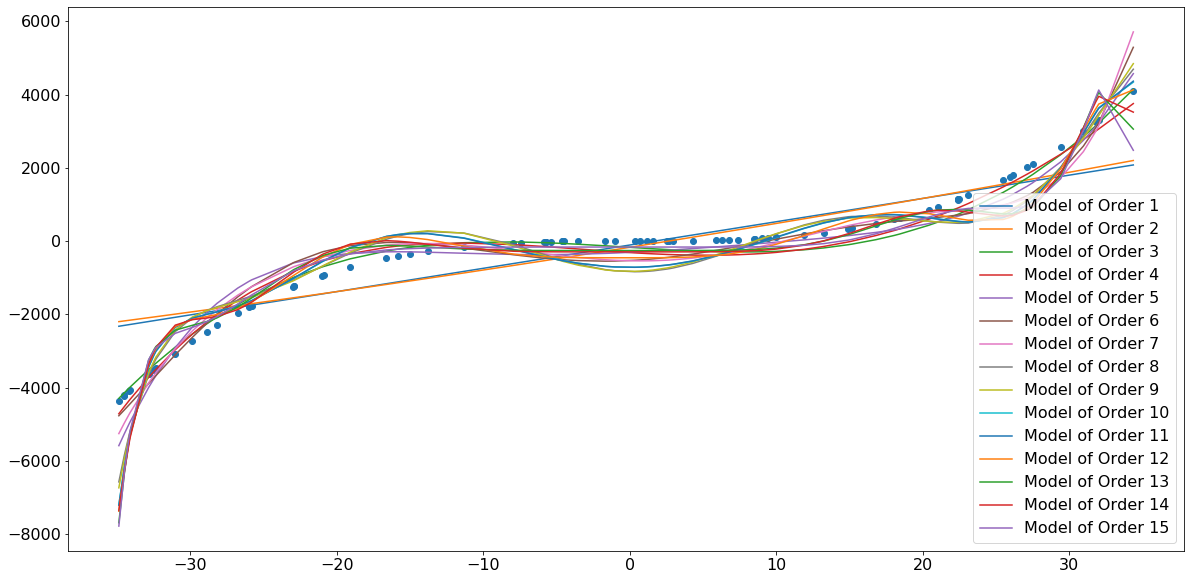

In [54]:
# Plotting one of every polynomial class
plt.figure(figsize=GRAPH_SIZE)
plt.scatter(np.split(test_data, 2, axis=1)[
            0], np.split(test_data, 2, axis=1)[1])
for order in range(MIN_ORDER, MAX_ORDER):
    for train_set in range(1):

        x_test = test_data[:, 0]
        shape = (len(x_test), 1)
        x_test = np.reshape(x_test, shape)

        plt.plot(x_test, predictions[order][train_set],
                 label='Model of Order '+str(order))
plt.legend()


In [55]:
# Lists to hold our squared bias, variance, MSE and IRE
bias_square = []
variance = []
mean_squared_error = []
irreducible_error = []

In [56]:
# Calculating average predictions (expectation)
np.set_printoptions(suppress=True)
average_pred = [[]]

for order in range(MIN_ORDER, MAX_ORDER):
    av_pred = np.mean(predictions[order], axis=0)
    average_pred.append(av_pred)

In [57]:
# Finding bias, variance and MSE for every order
for order in range(MIN_ORDER, MAX_ORDER):
    # Appended values
    var = 0
    bias = np.mean(
        (average_pred[order] - np.split(test_data, 2, axis=1)[1])**2)
    mse = 0

    # Finding variance and MSE
    for train_set in range(16):
        test_var = np.mean(
            (average_pred[order] - predictions[order][train_set])**2)
        test_mse = np.mean(
            (predictions[order][train_set] - np.split(test_data, 2, axis=1)[1])**2)

        var += test_var
        mse += test_mse

    var /= 16
    mse /= 16

    bias_square.append(bias)
    variance.append(var)
    mean_squared_error.append(mse)
    irreducible_error.append(mse - bias - var)

#tabulating IRE
table = pd.DataFrame(irreducible_error)
table.columns = ['Irreducible error']
table.index = range(MIN_ORDER, MAX_ORDER)
table


,Irreducible error
1,2.182787e-11
2,2.182787e-11
3,0.000000e+00
4,2.182787e-11
5,2.910383e-11
6,2.910383e-11
7,2.910383e-11
8,0.000000e+00
9,-2.910383e-11
10,-5.820766e-11


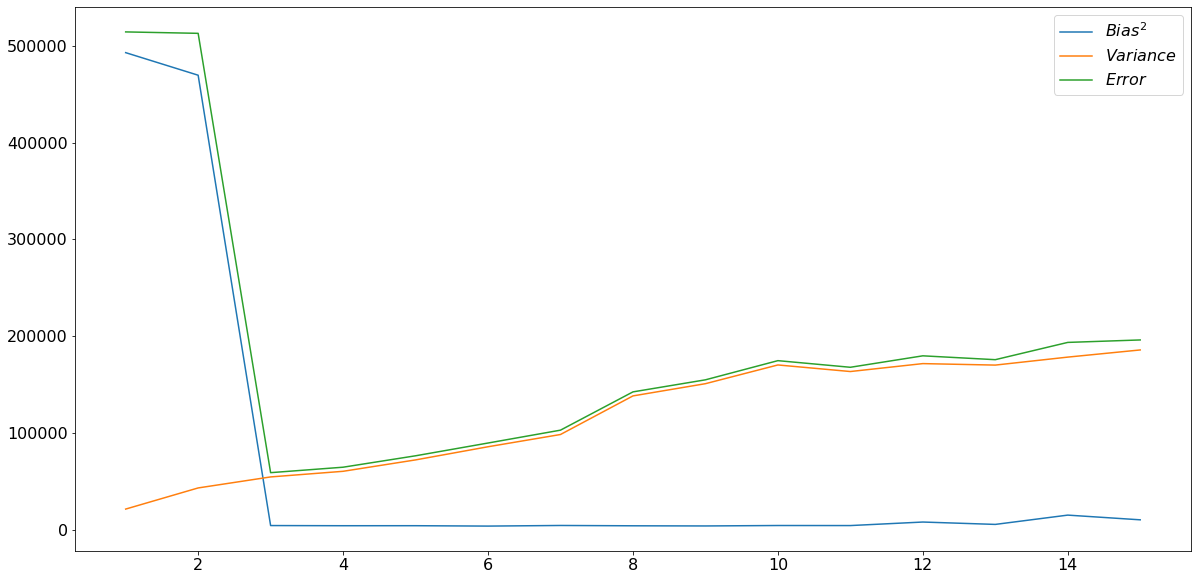

In [58]:
#Plotting Bias^2 - Variance Graph
x = [i for i in range(MIN_ORDER, MAX_ORDER)]
plt.figure(figsize=(20, 10))
plt.plot(x, bias_square, label="$Bias^2$")
plt.plot(x, variance, label="$Variance$")
plt.plot(x, mean_squared_error, label="$Error$")
plt.legend()
